**Goal:** Predict the next session type from ES daily volume-profile structure.

**Method:**
- Data/Sessions: ES 1-min bars; sessions = 09:30–09:29 ET.
- Profile: 55-bin typical-price volume; compute POC, VAH, VAL (70%).
- Labels: Compare today vs yesterday → Bullish/Bearish Gap, Expansion/Contraction, Bullish/Bearish Overlap.
- Stats: Base rates, streaks, 1/2/3-step transition matrices.
- Rules: Extract high-confidence 3-step sequences (max_prob ≥ 0.60, count ≥ 5).
- Modeling: RF on lagged labels (lags 1–20) with TimeSeriesSplit; report lift vs random/majority.
- Outputs: Frequency/transition tables, heatmaps, per-day profile plots.

**Use:** Gate signals and size risk only when a high-confidence rule or strong transition probability is present; else fall back to base rates.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
from collections import defaultdict


# Load and clean data
df = pd.read_csv(r"C:\Users\prath\Desktop\GridVision\5. Data\Core Data\ES_1Min(05.2020-05.2025).csv")
df.rename(columns={'Volume(from bar)': 'Volume'}, inplace=True)

# Remove colon in timezone to match format string
df['DateTime'] = df['DateTime'].str.replace(r'([-+]\d{2}):(\d{2})', r'\1\2', regex=True)

# Convert to datetime with explicit format to avoid warnings and improve speed
df['DateTime'] = pd.to_datetime(
    df['DateTime'],
    format="%Y-%m-%d %I:%M:%S %p %z",
    utc=True
).dt.tz_convert("America/New_York")

df['Date'] = df['DateTime'].dt.date


**Build Daily Profiles, Extract VAH/VAL/POC, and Classify vs Prior Day**

In [24]:
# SET PROFILE PARAMETERS
N_ROWS = 55           # Number of volume profile bins (rows) per day
VA_PERCENT = 0.7      # 70% value area

# Convert to datetime and localize to Eastern Time
df['DateTime'] = pd.to_datetime(df['DateTime'], utc=True).dt.tz_convert('America/New_York')

# Define session start as 9:30 AM Eastern Time
session_start = pd.to_datetime("09:30:00").time()

# Assign SessionDate based on 9:30 AM to 9:29 AM logic
df['SessionDate'] = df['DateTime'].apply(
    lambda dt: (dt - pd.Timedelta(days=1)).date() if dt.time() < session_start else dt.date()
)

# Function to build profile for a single session 
def build_profile(day_df):
    low = day_df['Low'].min()
    high = day_df['High'].max()
    price_range = high - low

    if price_range == 0 or day_df.empty:
        return {'VAH': np.nan, 'VAL': np.nan, 'POC': np.nan}

    bin_size = price_range / N_ROWS
    bins = np.arange(low, high + bin_size, bin_size)

    # Use typical price for more accurate volume assignment
    typical_price = (day_df['High'] + day_df['Low'] + day_df['Close']) / 3
    vol_profile = pd.cut(typical_price, bins=bins, include_lowest=True)
    volume_by_price = day_df.groupby(vol_profile, observed=True)['Volume'].sum()

    if volume_by_price.empty:
        return {'VAH': np.nan, 'VAL': np.nan, 'POC': np.nan}

    volume_by_price = volume_by_price.sort_index(ascending=False)
    total_volume = volume_by_price.sum()
    poc_price = volume_by_price.idxmax().mid

    # Build value area
    vol_cumsum = volume_by_price.iloc[volume_by_price.index.get_loc(volume_by_price.idxmax())]
    vah = val = poc_price
    idx = volume_by_price.index.get_loc(volume_by_price.idxmax())
    i_up, i_down = idx + 1, idx - 1

    while vol_cumsum / total_volume < VA_PERCENT:
        vol_up = volume_by_price.iloc[i_up] if i_up < len(volume_by_price) else 0
        vol_down = volume_by_price.iloc[i_down] if i_down >= 0 else 0

        if vol_up >= vol_down and i_up < len(volume_by_price):
            vol_cumsum += vol_up
            i_up += 1
        elif i_down >= 0:
            vol_cumsum += vol_down
            i_down -= 1
        else:
            break

    val = volume_by_price.index[min(i_up, len(volume_by_price) - 1)].right
    vah = volume_by_price.index[max(i_down + 1, 0)].left
    return {'VAH': vah, 'VAL': val, 'POC': poc_price}

# Classify session based on VA comparison
def classify_day(today, yesterday):
    if today['VAL'] > yesterday['VAH']:
        return "Bullish Gap"
    elif today['VAH'] < yesterday['VAL']:
        return "Bearish Gap"
    elif today['VAL'] < yesterday['VAL'] and today['VAH'] > yesterday['VAH']:
        return "Expansion"
    elif today['VAL'] > yesterday['VAL'] and today['VAH'] < yesterday['VAH']:
        return "Contraction"
    elif today['VAL'] > yesterday['VAL'] and today['VAH'] > yesterday['VAH']:
        return "Bullish Overlap"
    elif today['VAL'] < yesterday['VAL'] and today['VAH'] < yesterday['VAH']:
        return "Bearish Overlap"
    return "Unclassified"

# Process all sessions
daily_profiles = {}
for session_date, group in df.groupby('SessionDate'):
    profile = build_profile(group)
    daily_profiles[session_date] = profile

results = []
sorted_dates = sorted(daily_profiles.keys())

for i in range(1, len(sorted_dates)):
    today_date = sorted_dates[i]
    yesterday_date = sorted_dates[i - 1]

    today = daily_profiles[today_date]
    yesterday = daily_profiles[yesterday_date]

    label = classify_day(today, yesterday)
    results.append({
        'Date': today_date,
        'VAH': today['VAH'],
        'VAL': today['VAL'],
        'POC': today['POC'],
        'Classification': label
    })

# Final Results
session_types = pd.DataFrame(results)
session_types.tail()

,Date,VAH,VAL,POC,Classification
1552,2025-05-15,5952.655,5917.909,5934.6135,Bullish Gap
1553,2025-05-16,5974.623,5941.055,5975.1025,Bullish Overlap
1554,2025-05-18,5917.864,5896.768,5911.3340,Bearish Gap
1555,2025-05-19,5980.205,5955.091,5969.1250,Bullish Gap
1556,2025-05-20,5968.586,5951.691,5958.5295,Bearish Overlap


**Visualize Charts**

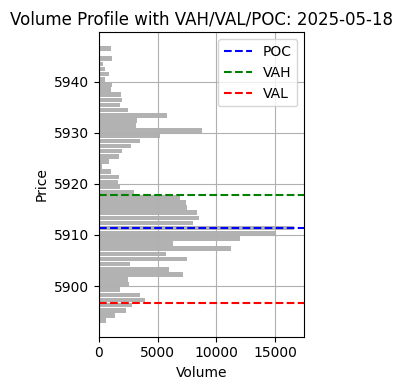

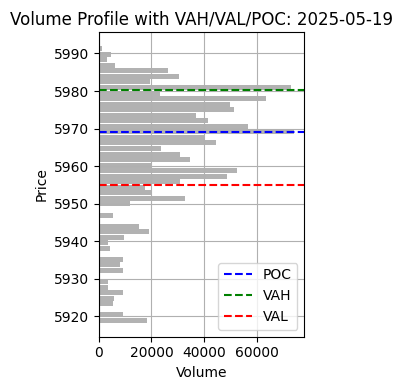

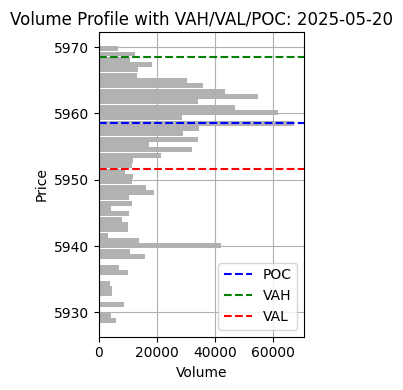

In [25]:

#  Plot daily volume profile with VAH, VAL, POC
def plot_profile_with_levels(day_df, profile, title):
    # Adaptive bin size based on day's price range
    low = day_df['Low'].min()
    high = day_df['High'].max()
    price_range = high - low

    if price_range == 0 or day_df.empty:
        print(f"Skipping {title} due to zero range or empty data")
        return

    bin_size = price_range / N_ROWS
    bins = np.arange(low, high + bin_size, bin_size)

    # Calculate typical price and volume per bin
    typical_price = (day_df['High'] + day_df['Low'] + day_df['Close']) / 3
    vol_profile = pd.cut(typical_price, bins=bins, include_lowest=True)
    volume_by_price = day_df.groupby(vol_profile, observed=True)['Volume'].sum()
    volume_by_price = volume_by_price.sort_index(ascending=False)

    prices = [interval.mid for interval in volume_by_price.index]
    volumes = volume_by_price.values

    # Plot volume profile
    fig, ax = plt.subplots(figsize=(3, 4))
    ax.barh(prices, volumes, height=bin_size * 0.9, color='gray', alpha=0.6)

    # Overlay VAH/VAL/POC lines
    ax.axhline(profile['POC'], color='blue', linestyle='--', label='POC')
    ax.axhline(profile['VAH'], color='green', linestyle='--', label='VAH')
    ax.axhline(profile['VAL'], color='red', linestyle='--', label='VAL')

    # Format plot
    ax.set_title(f"Volume Profile with VAH/VAL/POC: {title}")
    ax.set_xlabel("Volume")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Print profiles for last n days
valid_profiles = [d for d in sorted(daily_profiles.keys()) if all(pd.notna(list(daily_profiles[d].values())))]
recent_dates = valid_profiles[-3:]

for date in recent_dates:
    day_df = df[df['SessionDate'] == date]
    profile = daily_profiles[date]
    plot_profile_with_levels(day_df, profile, title=str(date))


**Basic Stats**

In [26]:

# Frequency count
session_counter = Counter(session_types["Classification"].tolist())
total_sessions = len(session_types)

frequency_df = pd.DataFrame.from_dict(session_counter, orient='index', columns=['Count'])
frequency_df['Percentage'] = (frequency_df['Count'] / total_sessions * 100).round(2)
frequency_df = frequency_df.sort_values(by='Count', ascending=False)

# Cluster analysis: detect streaks of repeated session types
cluster_data = defaultdict(list)
prev = None
count = 0

for curr in session_types["Classification"]:
    if curr == prev:
        count += 1
    else:
        if count >= 1:
            cluster_data[prev].append(count + 1)
        count = 0
    prev = curr
if count >= 1:
    cluster_data[prev].append(count + 1)

cluster_df = pd.DataFrame({
    'Session Type': cluster_data.keys(),
    'Clusters (≥2)': [len(v) for v in cluster_data.values()],
    'Max Cluster Length': [max(v) for v in cluster_data.values()],
    'Avg Cluster Length': [round(np.mean(v), 2) for v in cluster_data.values()]
}).set_index('Session Type')

# Merge frequency + cluster data
summary_df = frequency_df.join(cluster_df, how='left').fillna('-')
print("Frequency & Cluster Summary")
print(summary_df)

Frequency & Cluster Summary
                 Count  Percentage  Clusters (≥2)  Max Cluster Length  \
Bullish Overlap    362       23.25             67                   4   
Bullish Gap        353       22.67             59                   4   
Bearish Overlap    315       20.23             53                   4   
Bearish Gap        254       16.31             45                   4   
Expansion          141        9.06              7                   2   
Contraction        132        8.48              7                   2   

                 Avg Cluster Length  
Bullish Overlap                2.34  
Bullish Gap                    2.34  
Bearish Overlap                2.32  
Bearish Gap                    2.11  
Expansion                      2.00  
Contraction                    2.00  


- **Overlap sessions dominate:** Bullish/Bearish Overlaps together form ~43% of all sessions, making them the most common structure.
- **Gaps are also frequent:** Bullish and Bearish Gaps contribute ~39% combined, showing gaps are a significant recurring pattern.
- **Rare categories:** Expansion and Contraction together account for only ~17%, confirming they are uncommon states.
- **Streak dynamics:** Average cluster length is just ~2 sessions, with maximum streaks capped at 4 days across all types.
- **Implication:** Market structure rotates quickly, with only short-lived persistence, suggesting transition probabilities (Markov analysis) may provide more edge than raw clustering.

**Markov Transition Matrices**


 Transition Count Matrix
                 Bullish Gap  Bearish Overlap  Bullish Overlap  Expansion  \
Bullish Overlap           94               61               90         28   
Bullish Gap               79               74               80         40   
Expansion                 31               29               30          7   
Bearish Overlap           68               70               79         24   
Bearish Gap               51               59               57         19   
Contraction               30               22               25         23   

                 Bearish Gap  Contraction  
Bullish Overlap           61           28  
Bullish Gap               41           39  
Expansion                 30           14  
Bearish Overlap           47           26  
Bearish Gap               50           18  
Contraction               25            7  

 Transition Probability Matrix 
                 Bullish Gap  Bearish Overlap  Bullish Overlap  Expansion  \
Bullish Overlap 

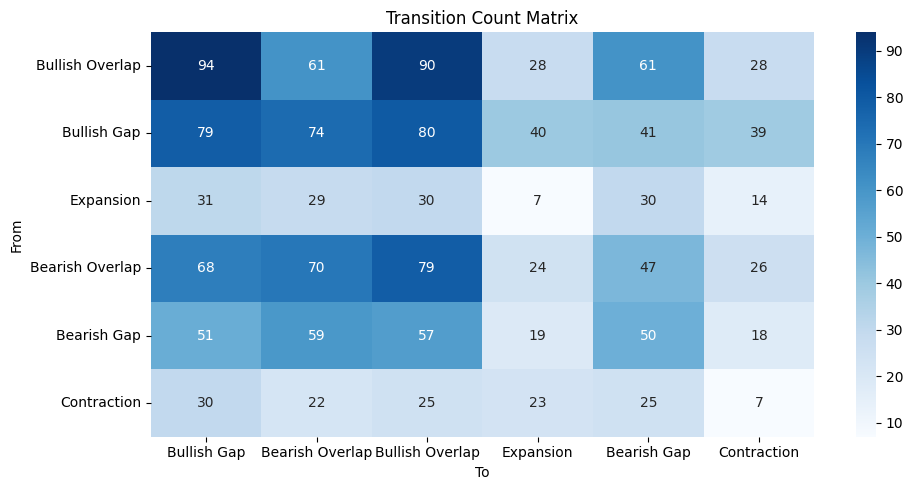

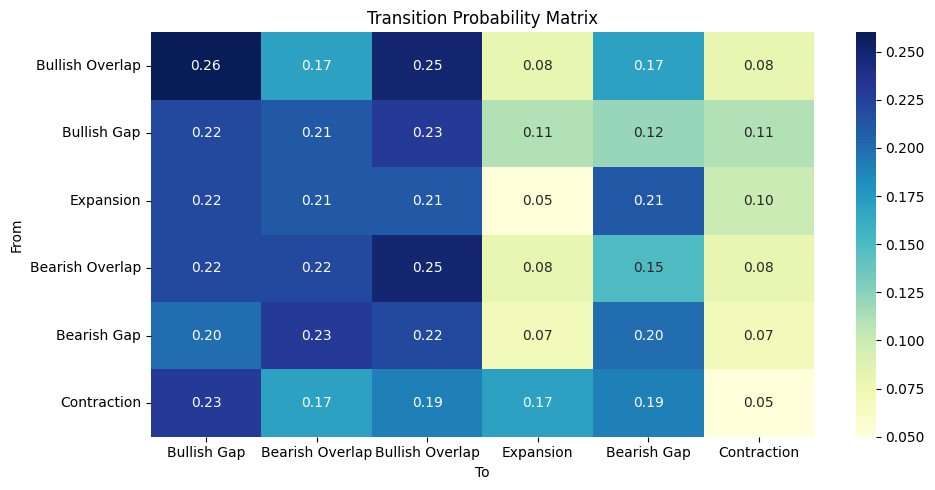


2-Step Transition Probability Matrix 
                                 Bearish Gap  Bearish Overlap  Bullish Gap  \
State -1        State 0                                                      
Bearish Gap     Bearish Gap             0.10             0.30         0.20   
                Bearish Overlap         0.12             0.27         0.19   
                Bullish Gap             0.14             0.25         0.20   
                Bullish Overlap         0.25             0.14         0.21   
                Contraction             0.28             0.17         0.17   
                Expansion               0.21             0.37         0.21   
Bearish Overlap Bearish Gap             0.26             0.17         0.11   
                Bearish Overlap         0.20             0.24         0.26   
                Bullish Gap             0.12             0.24         0.24   
                Bullish Overlap         0.13             0.18         0.28   
                Contracti

C:\Users\prath\AppData\Local\Temp\ipykernel_22316\1307136091.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  second_order_matrix = pd.DataFrame(index=multi_index, columns=next_states).fillna(0)


In [27]:
# Count transitions from t → t+1
session_list = session_types["Classification"].tolist()

transitions = defaultdict(lambda: defaultdict(int))
for i in range(len(session_list) - 1):
    curr, next_ = session_list[i], session_list[i + 1]
    transitions[curr][next_] += 1

# Build transition matrix
transition_df = pd.DataFrame(transitions).fillna(0).astype(int).T
transition_prob_df = transition_df.div(transition_df.sum(axis=1), axis=0).round(2)

print("\n Transition Count Matrix")
print(transition_df)

print("\n Transition Probability Matrix ")
print(transition_prob_df)

# Transition Count Matrix
plt.figure(figsize=(10, 5))
sns.heatmap(transition_df, annot=True, fmt='d', cmap='Blues')
plt.title("Transition Count Matrix")
plt.xlabel("To")
plt.ylabel("From")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Transition Probability Matrix
plt.figure(figsize=(10, 5))
sns.heatmap(transition_prob_df, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title("Transition Probability Matrix")
plt.xlabel("To")
plt.ylabel("From")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2-Step Markov Chain
second_order_counts = defaultdict(lambda: defaultdict(int))
for i in range(len(session_list) - 2):
    prev_pair = (session_list[i], session_list[i + 1])
    next_state = session_list[i + 2]
    second_order_counts[prev_pair][next_state] += 1

# Convert to MultiIndex DataFrame
state_pairs = sorted(second_order_counts.keys())
next_states = sorted({s for v in second_order_counts.values() for s in v})
multi_index = pd.MultiIndex.from_tuples(state_pairs, names=["State -1", "State 0"])

second_order_matrix = pd.DataFrame(index=multi_index, columns=next_states).fillna(0)
for pair, outcomes in second_order_counts.items():
    for next_state, count in outcomes.items():
        second_order_matrix.loc[pair, next_state] = count

second_order_prob_matrix = second_order_matrix.div(second_order_matrix.sum(axis=1), axis=0).round(2)

print("\n2-Step Transition Probability Matrix ")
print(second_order_prob_matrix)


In [28]:
# 3-Step Markov

# Get the sequence of labels as a plain list
session_list = session_types["Classification"].dropna().tolist()

third_order_counts = defaultdict(lambda: defaultdict(int))

# Need at least 4 observations for a 3-step transition
for i in range(len(session_list) - 3):
    prev_triplet = (session_list[i], session_list[i + 1], session_list[i + 2])
    next_state = session_list[i + 3]
    third_order_counts[prev_triplet][next_state] += 1

# If nothing accumulated (short data), you can early-exit
if not third_order_counts:
    print("Not enough data to build 3-step transitions.")
else:
    # Build matrix
    triplet_keys = sorted(third_order_counts.keys())
    all_states = sorted({s for d in third_order_counts.values() for s in d})

    idx = pd.MultiIndex.from_tuples(
        triplet_keys, names=["State -3", "State -2", "State -1"]
    )
    third_order_matrix = pd.DataFrame(index=idx, columns=all_states).fillna(0).astype(int)

    for triplet, outcomes in third_order_counts.items():
        for next_state, count in outcomes.items():
            third_order_matrix.loc[triplet, next_state] = count

    # Row-normalize to probabilities; avoid div-by-zero
    row_sums = third_order_matrix.sum(axis=1)
    third_order_prob_matrix = third_order_matrix.div(row_sums.replace(0, np.nan), axis=0).round(2)

    print("\n 3-Step Transition Probability Matrix")
    print(third_order_prob_matrix)



 3-Step Transition Probability Matrix
                                                 Bearish Gap  Bearish Overlap  \
State -3        State -2        State -1                                        
Bearish Gap     Bearish Gap     Bearish Gap             0.20             0.40   
                                Bearish Overlap         0.07             0.27   
                                Bullish Gap             0.20             0.10   
                                Bullish Overlap         0.11             0.11   
                                Contraction             0.17             0.00   
                                Expansion               0.00             0.40   
                Bearish Overlap Bearish Gap             0.14             0.14   
                                Bearish Overlap         0.19             0.31   
                                Bullish Gap             0.09             0.27   
                                Bullish Overlap         0.08          

C:\Users\prath\AppData\Local\Temp\ipykernel_22316\3092338235.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  third_order_matrix = pd.DataFrame(index=idx, columns=all_states).fillna(0).astype(int)


**High-Confidence 3-Step Session Structures**


In [29]:
# Get count of each 3-step sequence
third_order_counts_matrix = third_order_matrix.copy()
third_order_counts_matrix = third_order_counts_matrix.fillna(0).astype(int)

# Total transitions for each 3-step sequence
sequence_counts = third_order_counts_matrix.sum(axis=1)

# Filter by confidence and count thresholds
min_confidence = 0.6
min_count = 5

# Max probability for each 3-step sequence
max_probs = third_order_prob_matrix.max(axis=1)

# Apply both filters
qualified_rows = (max_probs >= min_confidence) & (sequence_counts >= min_count)

# Filter the main probability matrix first
high_confidence_rules = third_order_prob_matrix[qualified_rows].copy()

# Add metadata columns
high_confidence_rules['Max_Prob'] = max_probs[qualified_rows].values
high_confidence_rules['Next_Predicted_Type'] = third_order_prob_matrix.idxmax(axis=1)[qualified_rows].values
high_confidence_rules['Count'] = sequence_counts[qualified_rows].values

# Sort by confidence and support
high_confidence_rules = high_confidence_rules.sort_values(by=['Max_Prob', 'Count'], ascending=[False, False])

# Display results
pd.set_option('display.max_rows', None)
print(" High-Confidence 3-Step Session Structure Rules")
print(high_confidence_rules[['Max_Prob', 'Next_Predicted_Type', 'Count']])


 High-Confidence 3-Step Session Structure Rules
                                                 Max_Prob Next_Predicted_Type  \
State -3        State -2        State -1                                        
Expansion       Bearish Gap     Bearish Overlap      0.86     Bearish Overlap   
Bearish Overlap Expansion       Bearish Gap          0.60         Bullish Gap   
                                Contraction          0.60     Bullish Overlap   
Contraction     Bearish Gap     Bullish Gap          0.60     Bearish Overlap   
                Bearish Overlap Bearish Overlap      0.60     Bearish Overlap   
                Expansion       Bearish Gap          0.60     Bullish Overlap   
Expansion       Bullish Overlap Bearish Gap          0.60     Bearish Overlap   

                                                 Count  
State -3        State -2        State -1                
Expansion       Bearish Gap     Bearish Overlap      7  
Bearish Overlap Expansion       Bearish Gap        

- **Dominant rule:** The strongest sequence is Expansion → Bearish Gap → Bearish Overlap, which predicts Bearish Overlap next with 86% confidence (Count = 7)
- **Consistency:** Several contexts converge on Bearish Overlap as the predicted state, underscoring its role as a stable “magnet” regime after varied setups
- **Support:** Most rules sit at the minimum support cutoff (Count = 5), meaning they’re statistically thin and need higher sample accumulation for robustness
- **Takeaway:** Only a few 3-step contexts provide actionable predictability, with the standout being the 86% rule. Others highlight tendencies but should be treated cautiously due to low sample size


**Lag-Based Features and Random Forest Predictive Benchmarking**

In [ ]:
# Encode session types 
session_col = session_types["Classification"].dropna()
le = LabelEncoder()
encoded_sessions = le.fit_transform(session_col)

df = pd.DataFrame(
    {"session_type": session_col.values, "encoded": encoded_sessions},
    index=session_col.index
)

# Create lag features up to lag_3
for k in [1, 2, 3]:
    df[f"lag_{k}"] = df["encoded"].shift(k)

# Drop rows with NaNs introduced by shifting; cast lags back to int
df = df.dropna().copy()
for k in [1, 2, 3]:
    df[f"lag_{k}"] = df[f"lag_{k}"].astype(int)

y = df["encoded"]

# CV config (time-series safe) 
n_splits = min(5, max(2, len(df) // 50))
tscv = TimeSeriesSplit(n_splits=n_splits)
seeds = [23, 77, 111, 2024, 333]

def eval_model(X):
    scores_per_seed = []
    for seed in seeds:
        model = RandomForestClassifier(
            random_state=seed,
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            class_weight="balanced_subsample"  # handles class imbalance a bit
        )
        scores = cross_val_score(model, X, y, cv=tscv)
        scores_per_seed.append(scores.mean())
    return float(np.mean(scores_per_seed))

# Baselines
num_classes = y.nunique()
random_baseline = 1 / num_classes
majority_baseline = (y.value_counts().iloc[0] / len(y))

# Evaluate: lag_1, lag_1+lag_2, lag_1+lag_2+lag_3
results = {}
results["lag_1"] = eval_model(df[["lag_1"]])
results["lag_1_2"] = eval_model(df[["lag_1", "lag_2"]])
results["lag_1_2_3"] = eval_model(df[["lag_1", "lag_2", "lag_3"]])

#Print summary
print(f"\nTime-series CV ({n_splits} folds), avg over {len(seeds)} seeds")
for name, acc in results.items():
    lift_abs = acc - random_baseline
    lift_rel = (lift_abs / random_baseline) * 100
    print(f"{name:12s}: {acc:.3f} | lift vs random {lift_abs:.3f} ({lift_rel:.1f}%)")

print(f"\nBaselines -> Random: {random_baseline:.3f} | Majority: {majority_baseline:.3f}")

# Optional: quick feature importance on full fit (just indicative)
final_model = RandomForestClassifier(
    random_state=111, n_estimators=500, class_weight="balanced_subsample", n_jobs=-1
)
final_model.fit(df[["lag_1", "lag_2", "lag_3"]], y)
fi = dict(zip(["lag_1", "lag_2", "lag_3"], final_model.feature_importances_))
print("\nFeature importances (indicative, full-sample fit):", fi)



Time-series CV (5 folds), avg over 5 seeds
lag_1       : 0.170 | lift vs random 0.003 (1.9%)
lag_1_2     : 0.147 | lift vs random -0.020 (-11.8%)
lag_1_2_3   : 0.161 | lift vs random -0.006 (-3.6%)

Baselines -> Random: 0.167 | Majority: 0.232

Feature importances (indicative, full-sample fit): {'lag_1': np.float64(0.3246439792353078), 'lag_2': np.float64(0.3172396659493675), 'lag_3': np.float64(0.3581163548153248)}


- **Performance is weak:** accuracy hovers around the random baseline (0.167), with no lift from adding lag-2 or lag-3. The model doesn’t capture predictive structure beyond chance, and majority class baseline (0.232) outperforms all runs—highlighting strong class imbalance and limited signal in short lag sequences.

**Extended Lag-Depth Benchmarking: Random Forest Accuracy vs 1–20 Day History**


=== Grouped Classes: Bullish / Bearish / Expansion / Contraction ===
Classes found: ['Bearish', 'Bullish', 'Contraction', 'Expansion']
Random baseline: 0.250, Majority baseline: 0.456

lag_1_1     : 0.218 | lift vs random -0.032 (-13.0%)
lag_1_2     : 0.215 | lift vs random -0.035 (-13.9%)
lag_1_3     : 0.290 | lift vs random 0.040 (15.8%)
lag_1_4     : 0.302 | lift vs random 0.052 (20.6%)
lag_1_5     : 0.339 | lift vs random 0.089 (35.6%)
lag_1_6     : 0.369 | lift vs random 0.119 (47.6%)
lag_1_7     : 0.382 | lift vs random 0.132 (53.0%)
lag_1_8     : 0.402 | lift vs random 0.152 (60.9%)
lag_1_9     : 0.405 | lift vs random 0.155 (62.0%)
lag_1_10    : 0.407 | lift vs random 0.157 (62.7%)
lag_1_11    : 0.424 | lift vs random 0.174 (69.7%)
lag_1_12    : 0.415 | lift vs random 0.165 (66.1%)
lag_1_13    : 0.430 | lift vs random 0.180 (72.2%)
lag_1_14    : 0.427 | lift vs random 0.177 (70.8%)
lag_1_15    : 0.436 | lift vs random 0.186 (74.3%)
lag_1_16    : 0.439 | lift vs random 0.189 (7

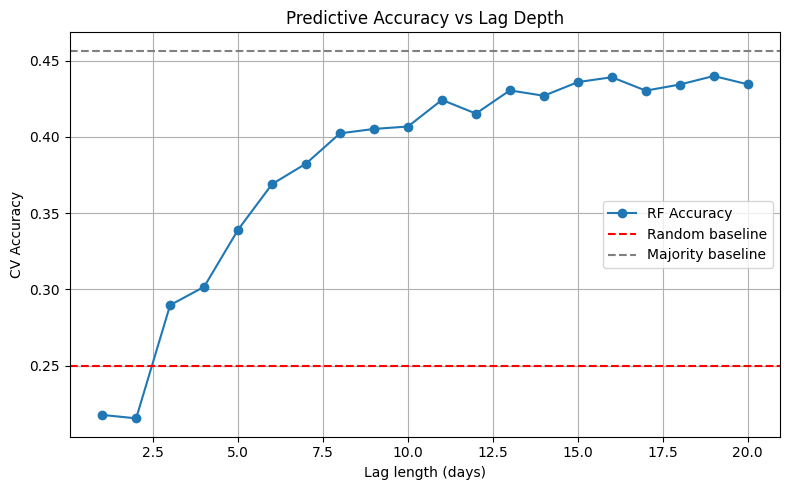

In [ ]:
# Create lag features 
MAX_LAG = 20
for k in range(1, MAX_LAG + 1):
    df[f"lag_{k}"] = df["encoded"].shift(k)

# Drop rows with NaN from shifting
df = df.dropna().copy()
for k in range(1, MAX_LAG + 1):
    df[f"lag_{k}"] = df[f"lag_{k}"].astype(int)

# Target
y = df["encoded"]

# CV setup
n_splits = min(5, max(2, len(df) // 50))
tscv = TimeSeriesSplit(n_splits=n_splits)
seeds = [23, 77, 111, 2024, 333]

def eval_model(X):
    scores_per_seed = []
    for seed in seeds:
        model = RandomForestClassifier(
            random_state=seed,
            n_estimators=300,
            n_jobs=-1,
            class_weight="balanced_subsample"
        )
        scores = cross_val_score(model, X, y, cv=tscv)
        scores_per_seed.append(scores.mean())
    return float(np.mean(scores_per_seed))

# Evaluate cumulative lags: lag_1, lag_1...2, ..., lag_1...20
results = {}
for k in range(1, MAX_LAG + 1):
    X = df[[f"lag_{i}" for i in range(1, k + 1)]]
    results[f"lag_1_{k}"] = eval_model(X)

# Baselines
num_classes = y.nunique()
random_baseline = 1 / num_classes
majority_baseline = (y.value_counts().iloc[0] / len(y))

print(f"\nGrouped Classes: Bullish / Bearish / Expansion / Contraction")
print(f"Classes found: {list(le.classes_)}")
print(f"Random baseline: {random_baseline:.3f}, Majority baseline: {majority_baseline:.3f}\n")

for name, acc in results.items():
    lift_abs = acc - random_baseline
    lift_rel = (lift_abs / random_baseline) * 100
    print(f"{name:12s}: {acc:.3f} | lift vs random {lift_abs:.3f} ({lift_rel:.1f}%)")

# Plot accuracy vs lag length
lags = [int(name.split("_")[-1]) for name in results.keys()]
accs = list(results.values())

plt.figure(figsize=(8,5))
plt.plot(lags, accs, marker="o", label="RF Accuracy")
plt.axhline(random_baseline, color="red", linestyle="--", label="Random baseline")
plt.axhline(majority_baseline, color="gray", linestyle="--", label="Majority baseline")
plt.xlabel("Lag length (days)")
plt.ylabel("CV Accuracy")
plt.title("Predictive Accuracy vs Lag Depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


- **Baseline comparison:** Random = 0.25, Majority = 0.456. The majority baseline remains the benchmark to beat.

- **Short lags underperform:** Using 1–2 lags yields worse than random (≈0.21), showing no predictive structure at shallow memory.

- **Signal emerges after ~3 lags:** Accuracy climbs steadily from lag-3 (0.29) up to lag-16/19 (~0.44).

- **Peak accuracy:** ~0.44 at 16–19 lags, which is just below the majority baseline (0.456). This indicates predictability improves with longer history, but still fails to consistently surpass the simplest majority-class strategy.

- **Lift vs random:** Gains are large relative to random (≈+75%), but this is misleading since the model still trails the majority baseline.

- **Implication:** Lag depth matters—longer context provides structure—but the classification scheme is imbalanced, and models can’t yet generate outperformance versus majority prediction.